<a href="https://colab.research.google.com/github/sekhahelina/bank_term_deposit_prediction/blob/main/deposit-prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Вітаю вас на Mid-term проєкті!

Цей проєкт призначений для того, щоб ви могли оновити та закріпити знання, які ви отримали за перші місяці навчання на курсі "Machine Learning для людей".

### Основна задача

В цьому завданні Ви - Data Scientist в барнку. Ваша задача - побудувати модель для передбачення, чи оформить клієнт в банку строковий депозит (term deposit). З подібними задачами ми стикаємось в різних компаніях і доменах, коли хочемо зрозуміти, чи клієнт купить якийсь продукт, чи буде користуватись нашим сервісом/сайтом у наступному місяці, чи придбає підписку.

Вам треба не просто побудувати модель, а і пояснити замовнику (ваш замовник тут - це ми з кураторами) як працює ця модель і чому вона дає саме такі рішення. Без цього розуміння ми не можемо перейти до впроваждення (деплойменту) моделі в продакшен.

### Практичне застовування

В реальних робочих умовах в подібних задачах у Вас дані будуть зберігатись в базі данних в динаміці (різні дії користувачів з датою і часом). Тут дані вже загреговані по клієнтам і часто саме з цього ви будете починати побудову моделі передбачення, адже це відносно просто і зручно: загрегувати дані по клієнтам до певного часу і передбачати в майбутнє (тільки в випадку тренування моделі ML наше "майбутнє" теж фактично в минулому - бо ми хочемо мати мітки в даних, а от вже при використанні моделі в продакшені і бойових умовах ви справді будете робити передбачення в майбутнє). Тож, розвʼязуємо задачку!

### Датасет і ML задача

Для виконання завдання ми використаємо набір даних, який оригінально походить з сайту [UCI Machine Learning Repository], але там неточний опис даних і багато різних піднаборів, тому ми братимемо з Kaggle dataset: https://www.kaggle.com/datasets/sahistapatel96/bankadditionalfullcsv.

Ці дані стосуються прямих маркетингових кампаній (телефонних дзвінків) португальської банківської установи. Кінцева мета класифікації - передбачити, чи підпише клієнт строковий депозит (змінна y).

Ми будемо працювати з файлом `bank-additional-full.csv`, скачати набір даних треба з Kaggle. Або можна скачати цей самий набір з гугл диска [тут](https://drive.google.com/file/d/1pDr0hAOnu1JsEiJeBu_F2Jv0GPxKiujW/view?usp=drive_link)

### Опис змінних

Цей опис є і на Kaggle, але ми переклали для вашої зручності і аби він був у вас перед очима під час роботи над проєктом.

#### **Дані про клієнта банку**:
1. **age** – вік клієнта (числова змінна).  
2. **job** – вид зайнятості (категоріальна змінна: `admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown`).  
3. **marital** – сімейний стан (категоріальна змінна: `divorced`, `married`, `single`, `unknown`; примітка: `divorced` означає розлучений або вдівець/вдова).  
4. **education** – рівень освіти (категоріальна змінна: `basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown`).  
5. **default** – чи є у клієнта прострочений кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
6. **housing** – чи має клієнт іпотечний кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
7. **loan** – чи має клієнт споживчий кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  

#### **Дані про останній контакт у межах поточної маркетингової кампанії**:
8. **contact** – тип зв’язку при останньому контакті (категоріальна змінна: `cellular`, `telephone`).  
9. **month** – місяць останнього контакту (категоріальна змінна: `jan`, `feb`, `mar`, …, `nov`, `dec`).  
10. **day_of_week** – день тижня останнього контакту (категоріальна змінна: `mon`, `tue`, `wed`, `thu`, `fri`).  
11. **duration** – тривалість останнього контакту в секундах (числова змінна).  
   ⚠ **Важлива примітка**: ця змінна має суттєвий вплив на цільову змінну (наприклад, якщо duration = 0, то y = `no`). Однак значення duration невідоме до здійснення дзвінка. Крім того, після завершення дзвінка значення y вже відоме. Тому цю змінну варто використовувати лише для порівняння моделей, але не включати у фінальну передбачувальну модель.  

#### **Інші атрибути**:
12. **campaign** – кількість контактів у межах поточної кампанії для цього клієнта (числова змінна, включає останній контакт).  
13. **pdays** – кількість днів, що минули з моменту останнього контакту клієнта у попередній кампанії (числова змінна; значення 999 означає, що клієнт раніше не контактувався).  
14. **previous** – кількість контактів, здійснених до цієї кампанії для цього клієнта (числова змінна).  
15. **poutcome** – результат попередньої маркетингової кампанії (категоріальна змінна: `failure`, `nonexistent`, `success`).  

#### **Атрибути соціально-економічного контексту**:
16. **emp.var.rate** – темп зміни зайнятості (щоквартальний показник, числова змінна).  
17. **cons.price.idx** – індекс споживчих цін (щомісячний показник, числова змінна).  
18. **cons.conf.idx** – індекс довіри споживачів (щомісячний показник, числова змінна).  
19. **euribor3m** – ставка Euribor на 3 місяці (щоденний показник, числова змінна).  
20. **nr.employed** – кількість працевлаштованих осіб (щоквартальний показник, числова змінна).  

#### **Цільова змінна**:
21. **y** – чи підписав клієнт строковий депозит? (бінарна змінна: `yes`, `no`).

### Ваше завдання на цей проєкт

Необхідно побудувати рішення цієї задачі бінарної класифікації. Для цього

1. Провести Exploratory Data Analysis і висунути гіпотези щодо впливу окремих ознак на цільову ознаку `y`.

2. Описати, які методи ви вважаєте доречним використовувати і обрати метрику оцінки якості моделей (метрику треба обґрунтувати).

3. Провести препроцесинг даних для подальшої їх передачі в модель. Препроцесинг має включати
  - обробку категоріальних змінних (якщо цього потребує модель)
  - групування категорій в категоріальних змінних, якщо потрібно
  - заповнення пропущених значень, якщо такі є
  - виявлення outliers і прийняття рішень, що з ними робити
  - створення додаткових ознак, які на ваш погляд поліпшать якість моделей ML.

4. Натренувати 4 різні типи моделей машинного навчання, з яких обовʼязково
  - Logistic Regression
  - kNN
  - Decision Tree
  - Принаймні один з алгоритмів бустингу

5. Створити таблицю з порівнянням якості моделей (в Google Spreadsheets або прямо в Jupyter Notebook), де зазначити
  - назву моделі
  - гіперпараметри
  - метрика якості моделі на тренувальному наборі
  - метрика якості моделі на валідаційному наборі даних
  - коментар до моделі - хороша вона, чи ні, чи варто її використовувати чи ні, чи є у вас подальші ідеї щодо експериментів з цією моделлю?

6. Для алгоритму бустингу виконати процедуру тюнингу гіперпараметрів двома способами
  - Sklearn: Randomized Search
  - Hyperopt: Bayesian Optimization.
  Виявити оптимальні гіперпараметри і зробити висновки про якість моделі в кожному з випадків.

7. Вивести важливість ознак для моделі, які показала себе найкраще і описати, чи вважаєте ви саме такий пріоритет важливості ознак адекватним з точки зору common sense?

8. Для найкращої провести аналіз впливу ознак на передбачення з допомогою бібліотеки SHAP.

9. Провести аналіз записів, в яких модель помиляється і на основі нього зазначити, яким чином можна поліпшити наявне рішення аби уникати наявних помилок?


### Результат виконання проєкту

Результатом виконання цього завдання є окремий github репозиторій з охайно оформленим Jupyter Notebook, частина коду може бути винесена в .py файли. Репозиторій має містити опис задачі, опис що було зроблено і які моделі використано, таблицю результатів експериментів (можна скріншотом або створити таблицю в Markdown форматі - див. Приклад) і висновки, що Ви досягли і що можна було б ще зробити для поліпшення результатів.


### Приклад проєкту

Для натхнення ви можете ознайомитись з проєктом, побудованим на основі цих даних за [цим посиланням](https://github.com/surtantheta/Bank_Marketing_Dataset_Machine_Learning_Project).




![](https://blogconcept2competence.wordpress.com/wp-content/uploads/2014/03/yoda.jpg)

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Імпорти необхідних бібліотек

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go


In [9]:
raw_df = pd.read_csv('/content/drive/MyDrive/dataframes/bank-additional-full.csv', sep=';')
raw_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [10]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [11]:
raw_df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [12]:
raw_df['y'].value_counts(normalize=True) * 100

,proportion
y,
no,88.734583
yes,11.265417


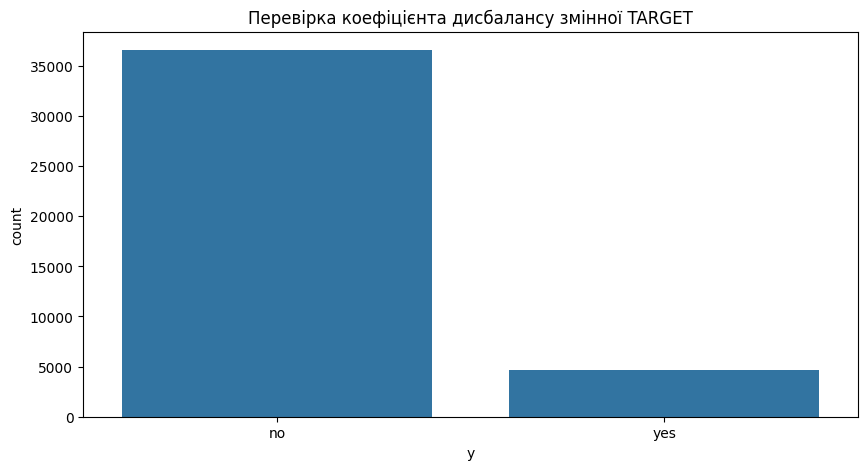

In [13]:
plt.figure(figsize = (10,5))
sns.countplot(x = raw_df['y'], data = raw_df)
plt.title('Перевірка коефіцієнта дисбалансу змінної TARGET')
plt.show()

In [14]:
for col in raw_df.select_dtypes('object'):
    print(raw_df[col].value_counts(dropna=False))

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64
contact
cellular     26144
telephone    15044
Name: count, dtype: in

In [15]:
num_cols = raw_df.select_dtypes(include='number').columns
cat_cols = raw_df.select_dtypes(include='object').columns

In [16]:
num_cols

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

In [17]:
cat_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')

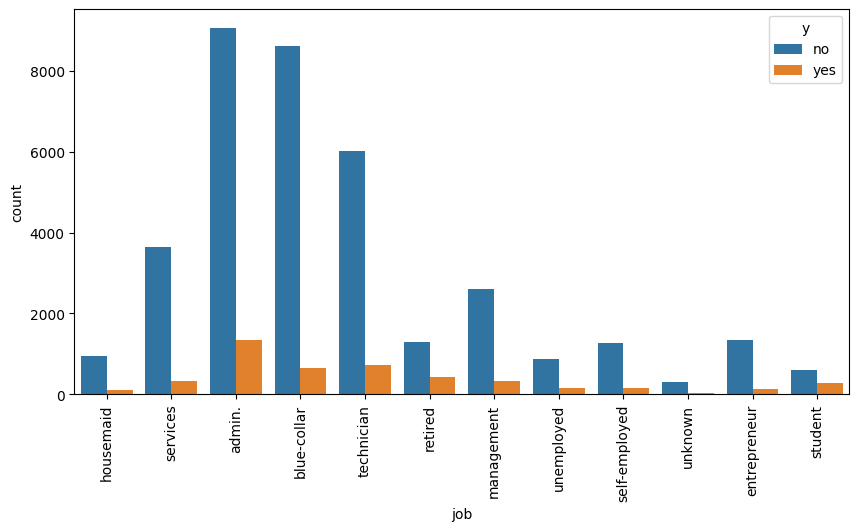

In [22]:
plt.figure(figsize = (10,5))
sns.countplot(data = raw_df, x = "job", hue = 'y')
plt.xticks(rotation = 90)
plt.show()

<Axes: xlabel='age', ylabel='Count'>

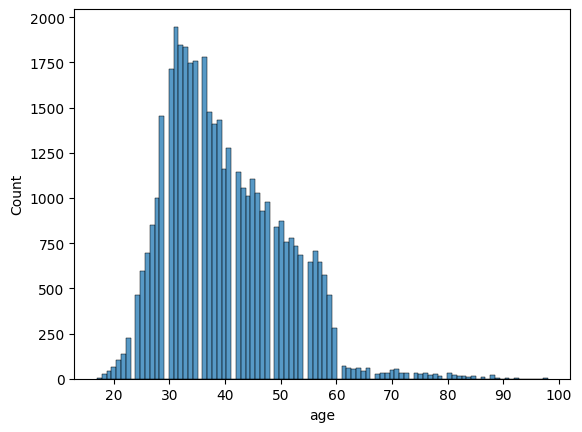

In [29]:
sns.histplot(data=raw_df, x= "age" )

<Axes: xlabel='age', ylabel='Density'>

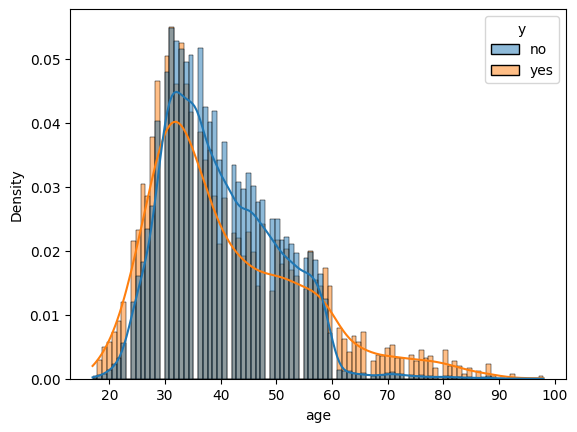

In [26]:
sns.histplot(
    data=raw_df,
    x='age',
    hue='y',
    kde=True,
    stat='density',
    common_norm=False
)

Люди молодшого віку (студенти) та старшого віку (пенсіонери) мають вищу конверсію (ймовірність відкриття строкового депозиту) порівняно з людьми середнього працездатного віку.

<Axes: xlabel='campaign', ylabel='Density'>

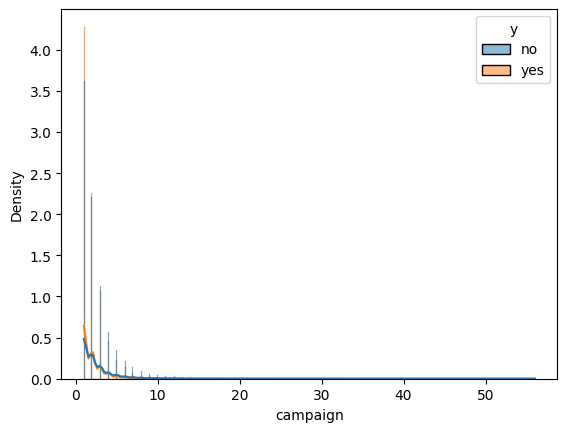

In [39]:
sns.histplot(
    data=raw_df,
    x='campaign',
    hue='y',
    kde=True,
    stat='density',
    common_norm=False
)

Обрізаємо хвіст щоб краще побачити розподіл

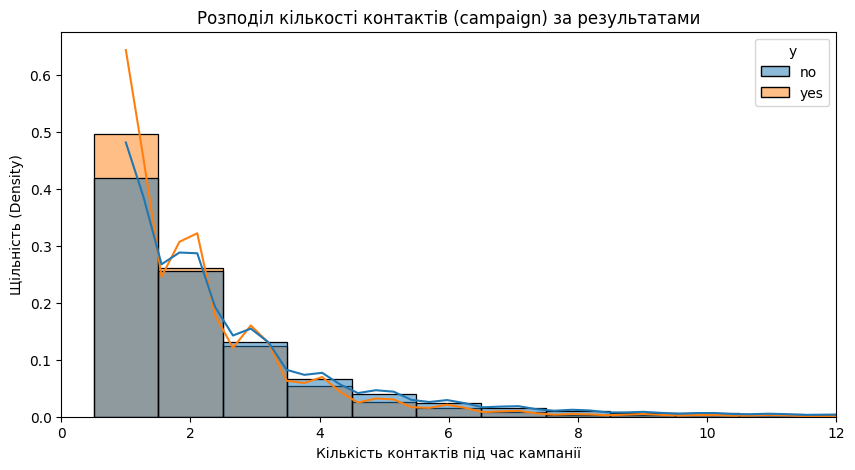

In [40]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=raw_df,
    x='campaign',
    hue='y',
    kde=True,
    stat='density',
    common_norm=False,
    discrete=True # Оскільки campaign — це цілі числа
)
plt.xlim(0, 12) # Обрізаємо порожній "хвіст"
plt.title('Розподіл кількості контактів (campaign) за результатами')
plt.xlabel('Кількість контактів під час кампанії')
plt.ylabel('Щільність (Density)')
plt.show()

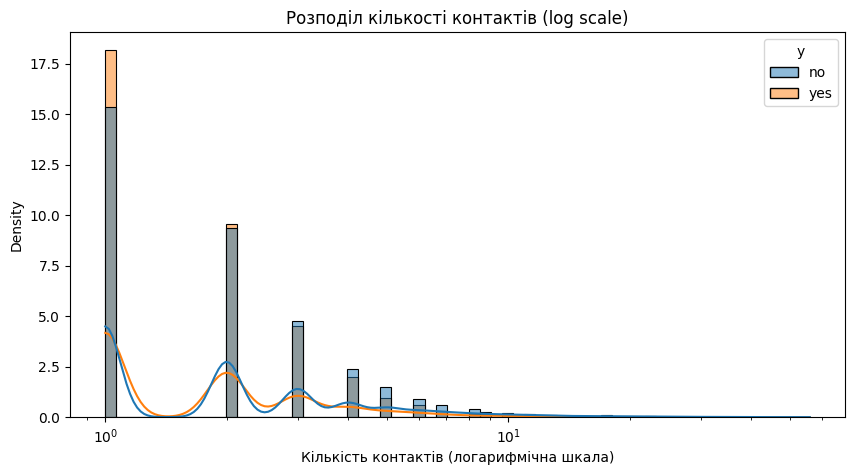

In [41]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=raw_df,
    x='campaign',
    hue='y',
    kde=True,
    stat='density',
    common_norm=False,
    log_scale=True # Вмикаємо логарифмічну шкалу для осі X
)
plt.title('Розподіл кількості контактів (log scale)')
plt.xlabel('Кількість контактів (логарифмічна шкала)')
plt.show()

Додаткові дзвінки після 3–4 спроб не збільшують ймовірність згоди, а лише витрачають ресурси банку. Ефективніше обмежити кількість контактів на одного клієнта (наприклад, не більше 3-4 за кампанію). Клієнти погоджуються з першого-2 дзвінка, більше дзвінків не гарантує погождення, а навпаки зменшує ймовірність згоди.

<Axes: xlabel='duration', ylabel='Density'>

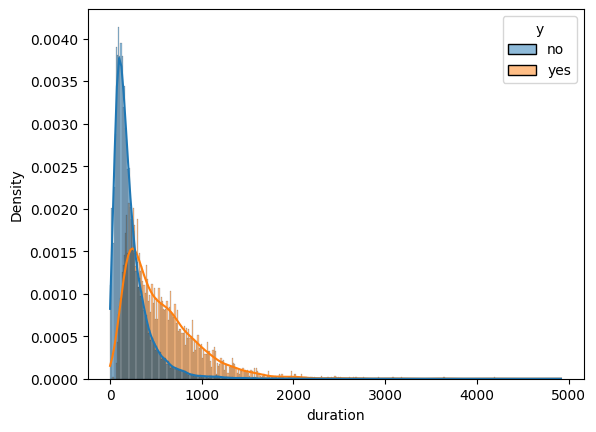

In [44]:
sns.histplot(
    data=raw_df,
    x='duration',
    hue='y',
    kde=True,
    stat='density',
    common_norm=False
)

Графік показує чітку залежність між тривалістю дзвінка (duration) та цільовою змінною y: чим триваліша розмова, тим вища ймовірність того, що клієнт погодиться на депозит (yes).

Однак зміна duration створює витік даних (data leakage). Тривалість розмови відома лише після здійснення дзвінка, коли результат (y) уже фактично зафіксовано. Оскільки мета моделі — передбачити схильність клієнта до дзвінка (щоб пріоритеризувати базу), змінну duration необхідно вилучити з набору ознак для тренування моделі."

<Axes: xlabel='previous', ylabel='Density'>

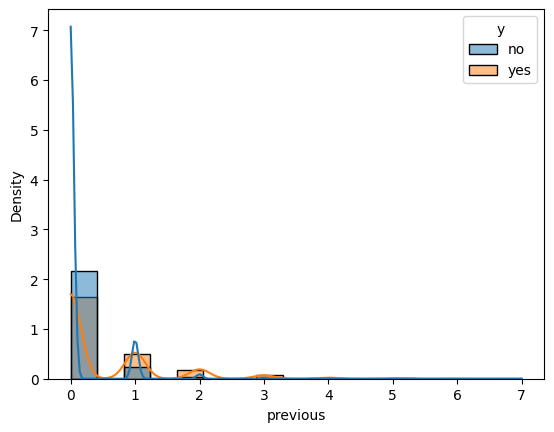

In [45]:
sns.histplot(
    data=raw_df,
    x='previous',
    hue='y',
    kde=True,
    stat='density',
    common_norm=False
)

Наявність попередніх контактів (previous > 0) підвищує ймовірність (конверсію) того, що клієнт погодиться на депозит у поточній кампанії. Клієнти, з якими банк уже взаємодіяв раніше, більш схильні до згоди, ніж "холодні" клієнти (previous = 0).

Однак основний обсяг нових депозитів у абсолютних цифрах банк отримує саме від клієнтів з previous = 0, оскільки вони становлять абсолютну більшість вибірки.

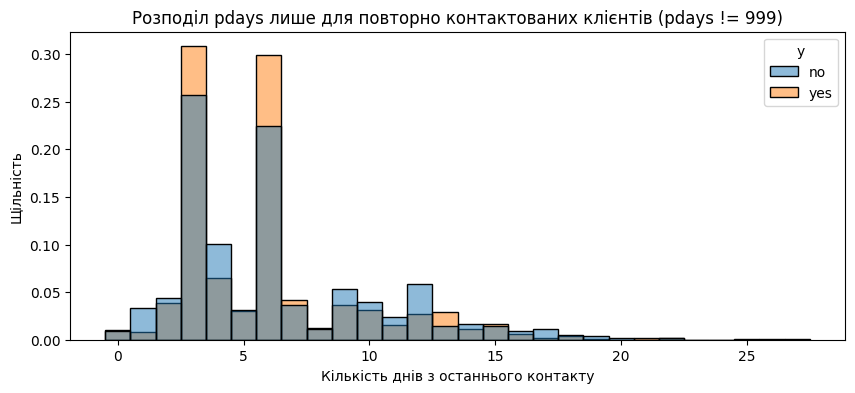

In [51]:
plt.figure(figsize=(10, 4))
sns.histplot(
    data=raw_df[raw_df['pdays'] != 999],
    x='pdays',
    hue='y',
    discrete=True,
    stat='density',
    common_norm=False
)
plt.title('Розподіл pdays лише для повторно контактованих клієнтів (pdays != 999)')
plt.xlabel('Кількість днів з останнього контакту')
plt.ylabel('Щільність')
plt.show()

<Axes: xlabel='pdays', ylabel='Density'>

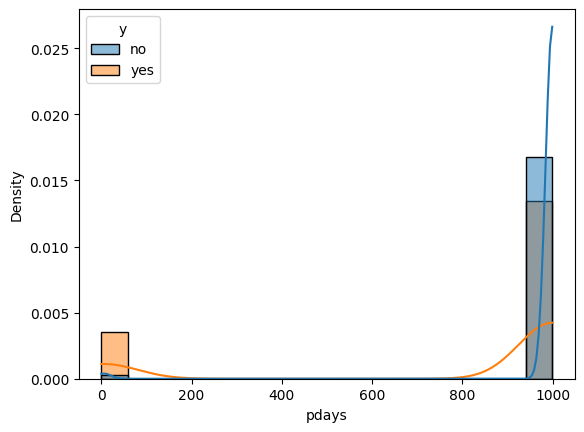

In [50]:
sns.histplot(
    data=raw_df,
    x='pdays',
    hue='y',
    kde=True,
    stat='density',
    common_norm=False
)

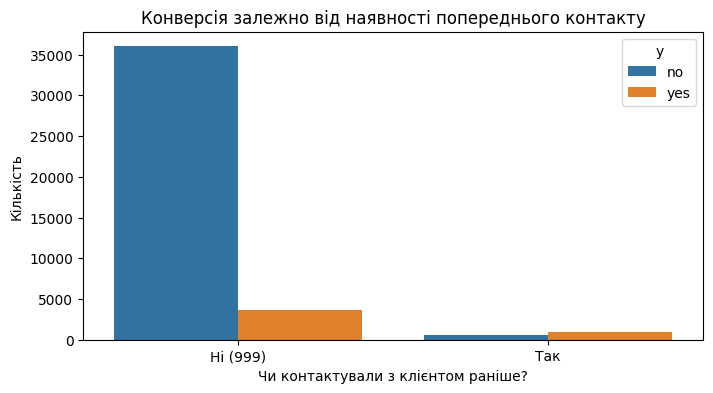

In [52]:
# 1. Створюємо прапорець
raw_df['pdays_contacted'] = raw_df['pdays'].apply(lambda x: 'Ні (999)' if x == 999 else 'Так')

# 2. Будуємо countplot для конверсії
plt.figure(figsize=(8, 4))
sns.countplot(data=raw_df, x='pdays_contacted', hue='y')
plt.title('Конверсія залежно від наявності попереднього контакту')
plt.xlabel('Чи контактували з клієнтом раніше?')
plt.ylabel('Кількість')
plt.show()

база повторно контактованих клієнтів є значно лояльнішою та ефективнішою для дзвінків, хоча основний валовий приплив депозитів банк все одно отримує за рахунок масштабу від нових клієнтів.

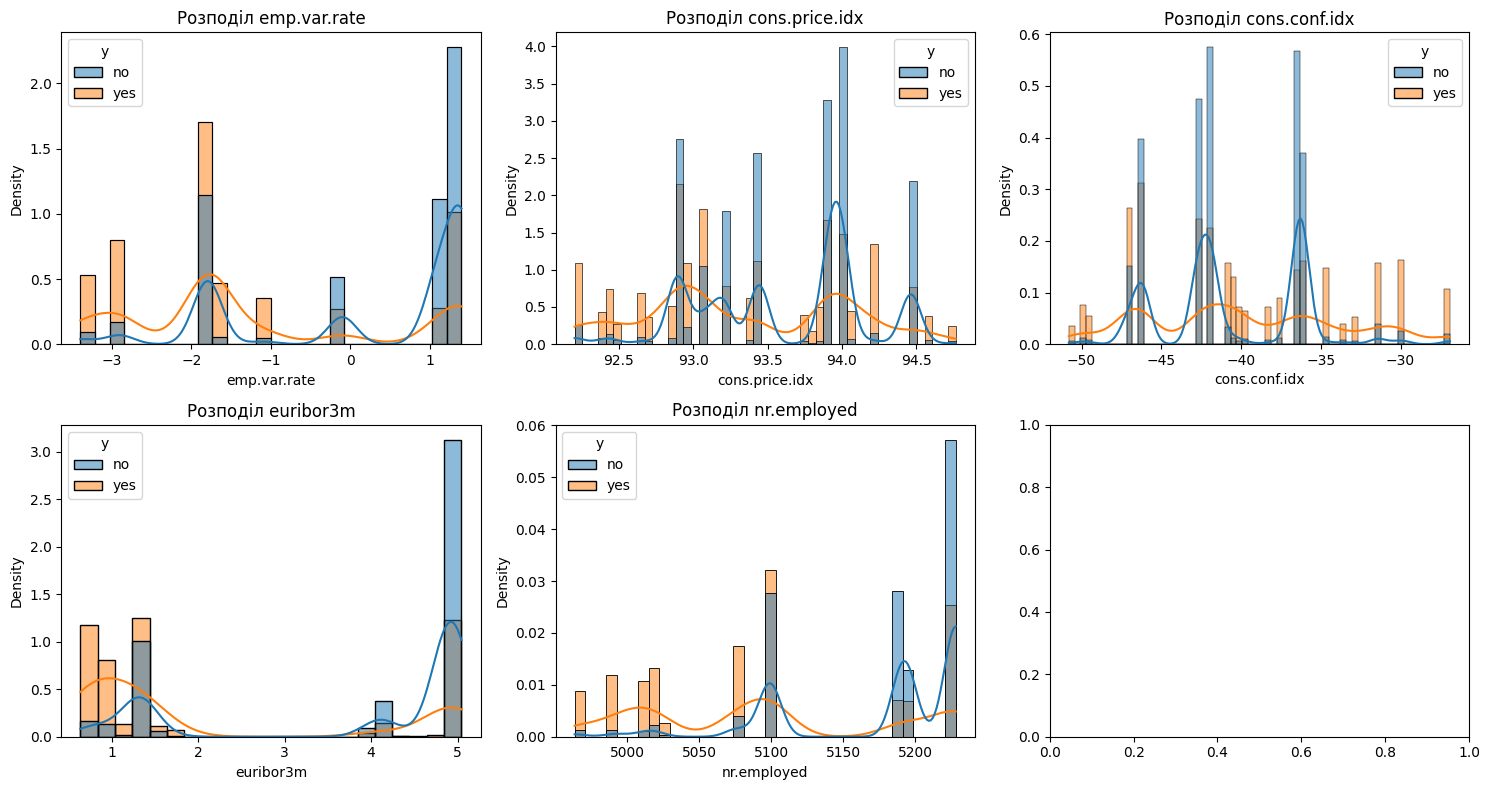

In [53]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
socio_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

for ax, col in zip(axes.flatten(), socio_cols):
    sns.histplot(data=raw_df, x=col, hue='y', stat='density', common_norm=False, kde=True, ax=ax)
    ax.set_title(f'Розподіл {col}')

plt.tight_layout()
plt.show()

Бізнес-висновок: Клієнти набагато активніше відкривають депозити в періоди низьких відсоткових ставок та економічного спаду/невизначеності. За високих ставок або росту економіки інтерес до строкових депозитів у даній кампанії був суттєво нижчим. Графіки показують, що euribor3m, emp.var.rate та nr.employed рухаються майже однаково і мають дублюючу інформацію. У них висока кореляція

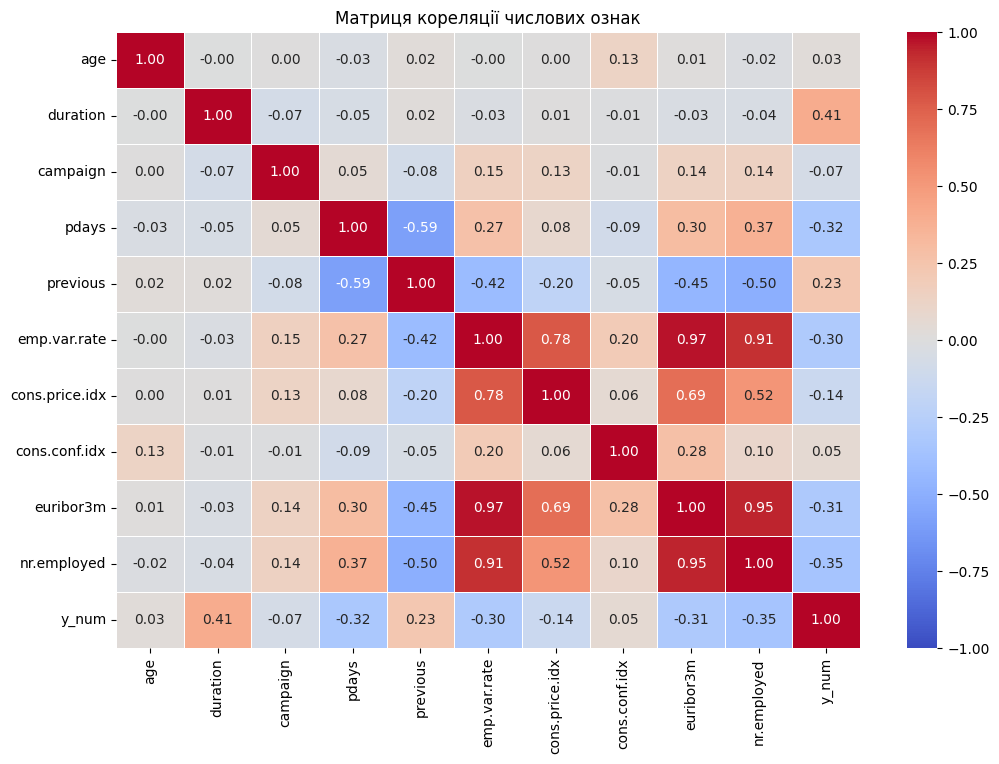

In [54]:
plt.figure(figsize=(12, 8))

# Створюємо копію числових колонок і додаємо числовий y
num_data = raw_df[num_cols].copy()
num_data['y_num'] = (raw_df['y'] == 'yes').astype(int)

# Рахуємо матрицю кореляції (Spirman або Pearson)
corr_matrix = num_data.corr()

# Малюємо Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Матриця кореляції числових ознак')
plt.show()

Висока мультиколінеарність

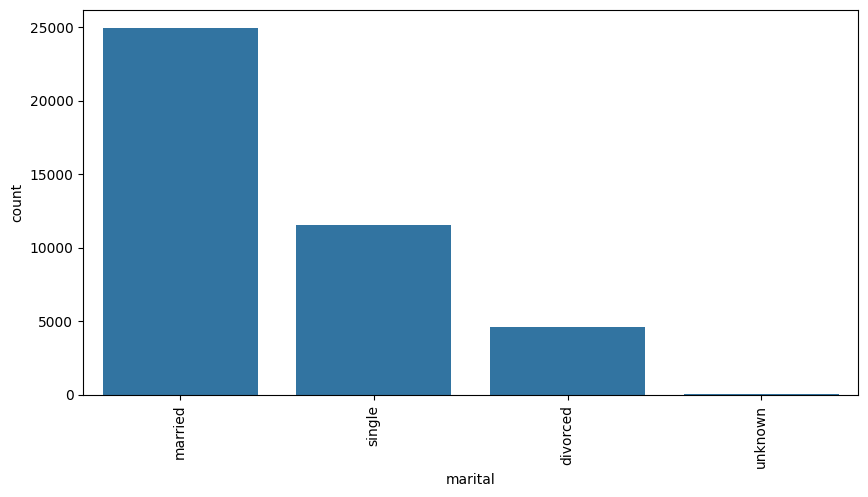

In [19]:
plt.figure(figsize = (10,5))
sns.countplot(data = raw_df, x = "marital")
plt.xticks(rotation = 90)
plt.show()

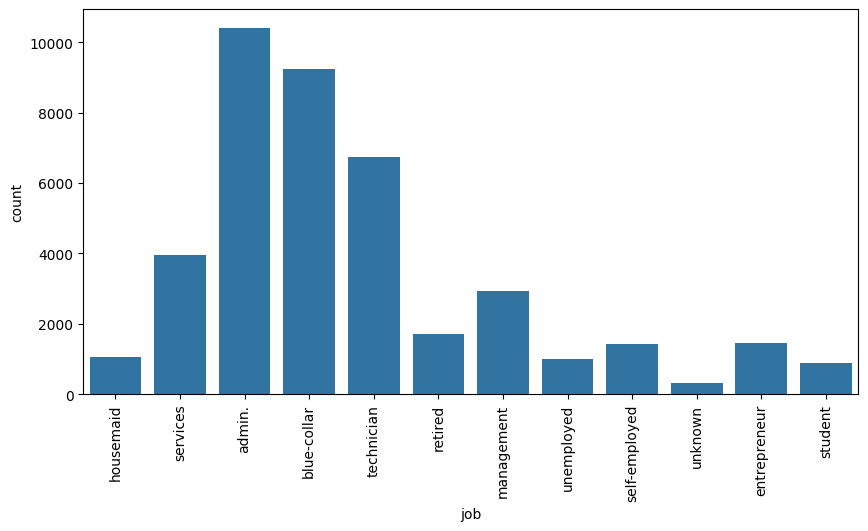

In [55]:
plt.figure(figsize = (10,5))
sns.countplot(data = raw_df, x = "job")
plt.xticks(rotation = 90)
plt.show()

на цьому графіку бачимо підтвердження яке ми робили коли аналізували вік, найбільше депозитів беруть студенти та пенсіонери, більш стабільні працевлаштоані люди відсотково роблять це менше. Проте це може бути повязано з тим що для цих категорій у нас найменше зразків даних.

In [73]:
# 1. Абсолютна кількість
fig_count = px.histogram(
    raw_df, x='job', color='y', barmode='group',
    title='Кількість клієнтів (Абсолютний обсяг)'
)
fig_count.show()

# 2. Відсотки
fig_percent = px.histogram(
    raw_df, x='job', color='y', barnorm='percent', barmode='group',
    title='Частка конверсії (%)'
)
fig_percent.show()

In [74]:
def plot_relative_and_absolute(df, column_name, target_col='y'):
    """
    Будує два графіки для категоріальної колонки:
    1. Абсолютна кількість клієнтів за категоріями (Count)
    2. Відсоткова частка конверсії всередині кожної категорії (%)
    """
    # 1. Абсолютна кількість
    fig_count = px.histogram(
        df,
        x=column_name,
        color=target_col,
        barmode='group',
        title=f'Кількість клієнтів (Абсолютний обсяг) — {column_name}',
        category_orders={target_col: ['no', 'yes']}
    )
    fig_count.update_layout(
        xaxis_title=column_name.capitalize(),
        yaxis_title='Кількість клієнтів',
        legend_title='Депозит'
    )
    fig_count.show()

    # 2. Відсотки (Нормалізований розподіл)
    fig_percent = px.histogram(
        df,
        x=column_name,
        color=target_col,
        barnorm='percent',
        barmode='group',
        title=f'Частка конверсії (%) — {column_name}',
        category_orders={target_col: ['no', 'yes']}
    )
    fig_percent.update_layout(
        xaxis_title=column_name.capitalize(),
        yaxis_title='Частка (%)',
        legend_title='Депозит'
    )
    fig_percent.show()

In [75]:
plot_relative_and_absolute(raw_df, 'education')

In [83]:
raw_df.education.value_counts()

,count
education,
university.degree,12168
high.school,9515
basic.9y,6045
professional.course,5243
basic.4y,4176
basic.6y,2292
unknown,1731
illiterate,18


тут я б звернула увагу на юніерсіті та анновн, бо неосвічені мають дужеее мало даних

In [76]:
plot_relative_and_absolute(raw_df, 'marital')

Впринципі не несе ніякої корисної інформації, тому що розподіл відсотковий для всіх категорій майже одинаковий.

In [77]:
plot_relative_and_absolute(raw_df, 'contact')

In [85]:
cat_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')

In [88]:
plot_relative_and_absolute(raw_df, 'poutcome')

In [93]:
plot_relative_and_absolute(raw_df, 'default')

In [90]:
raw_df.default.value_counts()

,count
default,
no,32588
unknown,8597
yes,3


In [21]:
fig=px.scatter(df,x='total_bill', y='tip', color='sex',
               title='Рахунок vs чайові',
               labels={'total_bill': 'Рахунок', 'tip':'Чайові', 'sex':'Стать'}
               )
fig.show()

NameError: name 'df' is not defined